In [4]:
import utils
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt
import pefile
import numpy as np

mpl.rcParams["figure.dpi"] = 300

dataset = utils.data.MalwareDataset()

In [5]:
def get_size(path):
    try:
        pe = pefile.PE(path, fast_load=True)
        size = pe.dump_dict()["OPTIONAL_HEADER"]["SizeOfCode"]["Value"]
        return size
    except:
        return 0

In [6]:
malware_size = []
benign_size = []

for path, label in tqdm(dataset):
    size = get_size(path)
    if label == 0:
        benign_size.append(size)
    else:
        malware_size.append(size)

100%|██████████| 11115/11115 [07:16<00:00, 25.48it/s] 


In [9]:
malware_size = np.array(malware_size)
benign_size = np.array(benign_size)

print(f"Min: {malware_size.min()}, Max: {malware_size.max()}, No: {len(malware_size)}")
print(f"Min: {benign_size.min()}, Max: {benign_size.max()}, No: {len(benign_size)}")

Min: 0, Max: 1766614113, No: 5792

Min: 0, Max: 502944256, No: 5323

Text(0.5, 0, 'Executable Kind')

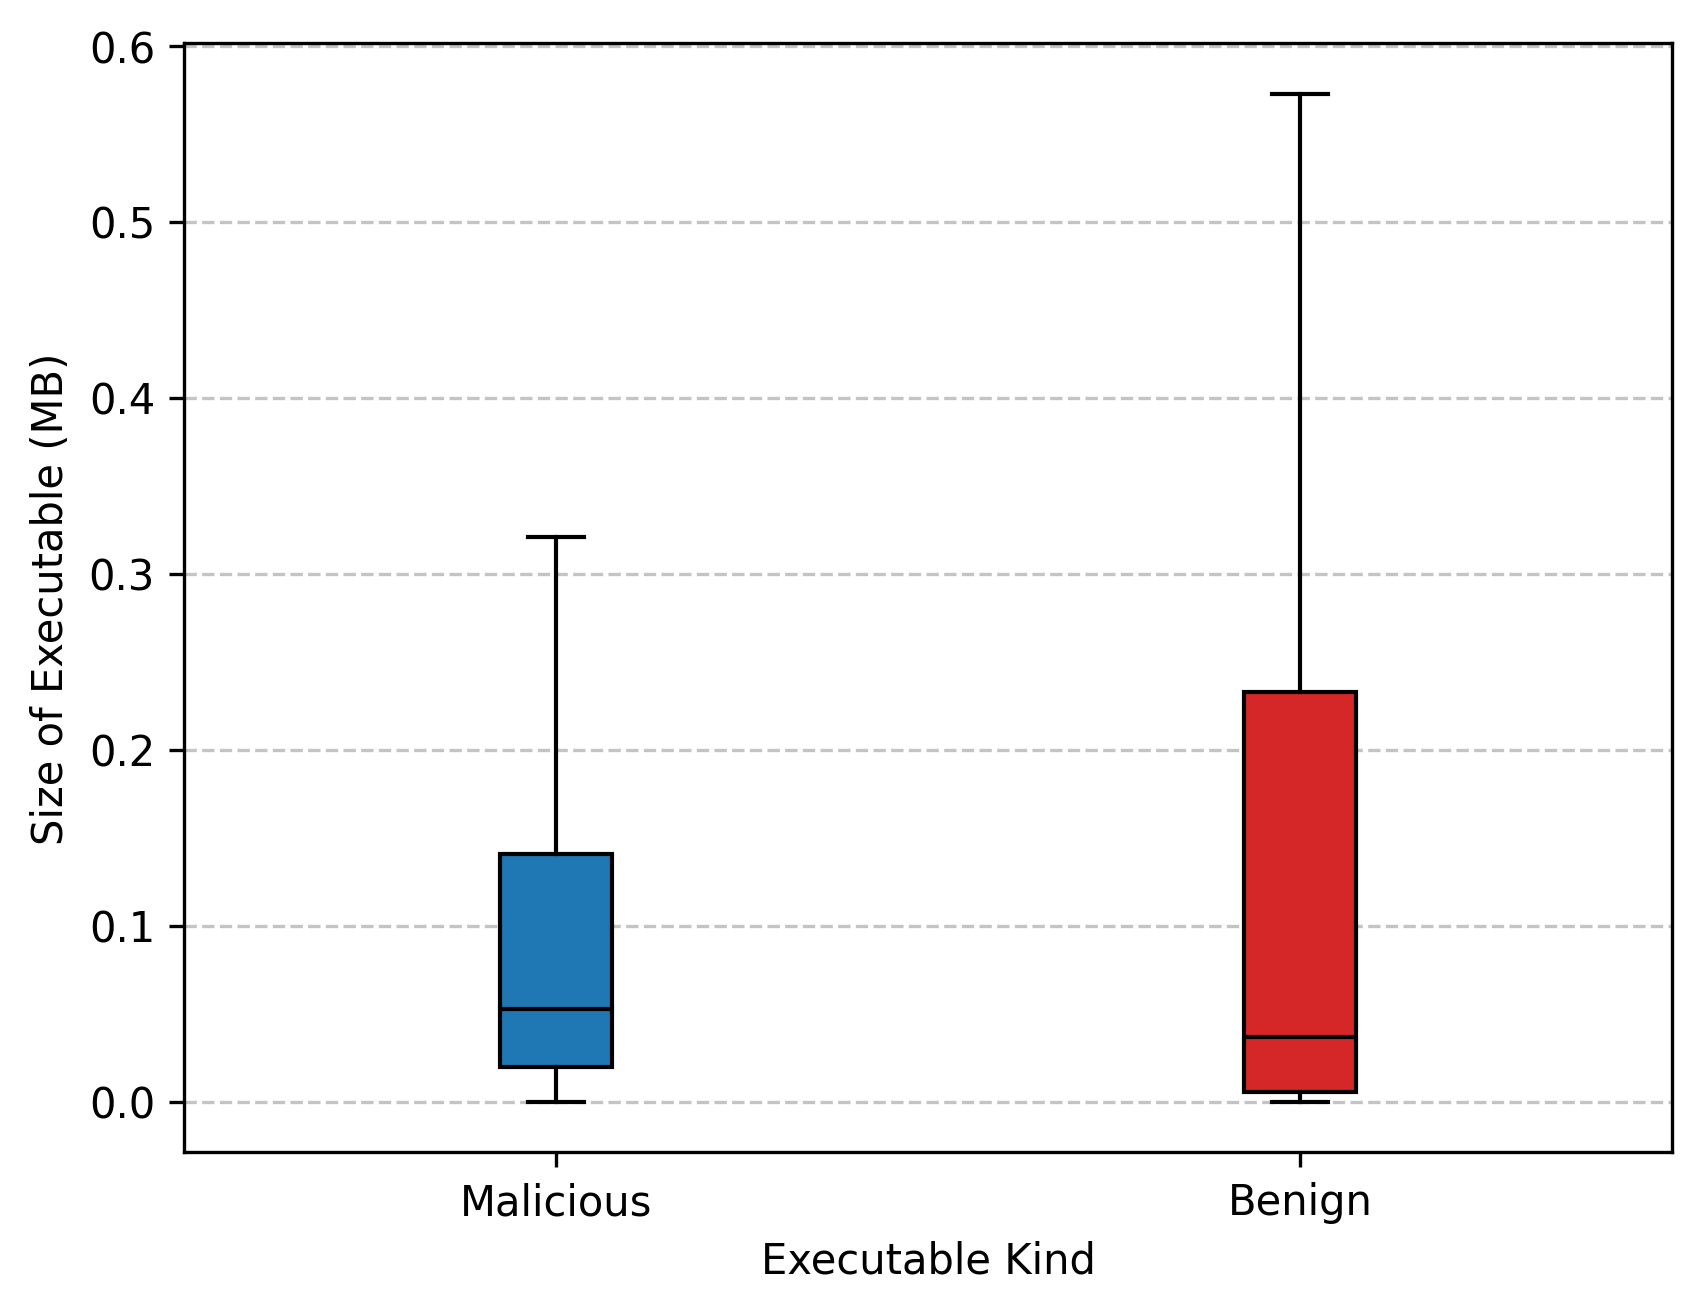

In [17]:
bp = plt.boxplot(
    [malware_size / 1024**2, benign_size / 1024**2],
    vert=True,
    patch_artist=True,
    tick_labels=["Malicious", "Benign"],
    medianprops={"color": "black"},
    sym="",
)

for box, color in zip(bp["boxes"], ["tab:blue", "tab:red"]):
    box.set(facecolor=color)
plt.grid(axis="y", linestyle="--", alpha=0.75)
plt.ylabel("Size of Executable (MB)")
plt.xlabel("Executable Kind")